In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import (
    load_and_process_results,
    match_datasets,
    matching_precision_recall,
    get_filenames_in_directory,
    fit_temperature,
    apply_temperature,
    fit_temperature_from_probs,
    apply_temperature_from_probs,
)
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Ground Truth Dataset

In [3]:
# ---------------------------------
# Load from ground truth dataset
# ---------------------------------

# Directory
with open(os.path.join("../data/nfix/directory.json"), "r") as f:
    paper_info = json.load(f)

def text_or_table_extraction(location):
    if 'figure' in location:
        return False
    if 'supplement' in location:
        return False
    if 'archive' in location:
        return False
    if 'author' in location:
        return False
    else:
        return True

registered_paper_info = {R: Rinfo for R,Rinfo in paper_info.items() if text_or_table_extraction(Rinfo['extraction_location'])}

paper_subset = [
    "R163", "R164", "R172", "R248", "R124",
    "R51", "R59", "R114", "R43", "R103",
]

registered_paper_info = {R: Rinfo for R,Rinfo in paper_info.items() if R in paper_subset}
registered_ids = list(registered_paper_info.keys())

ground_truth_df = pd.read_csv("../data/nfix/meta/aquatic_N2fix_rates.csv")
ground_truth_df = ground_truth_df.loc[ground_truth_df.reference_id.isin(registered_ids)]

id_cols = [
    'nfix_rate_id', 'reference_id', 'site_name', 'latitude', 'longitude',
    'habitat', 'year', 'month', 'day', 'hour_minute', 'season',
    'substrate', 'substrate_details'
]

# Build a list of records, one per attribute
records = []

# 1) nfix_rate_original -> attribute="rate_original"
#    error from nfix_error_original, error_type from nfix_error_type,
#    units from nfix_unit_original
records.append(ground_truth_df[id_cols].assign(
    attribute='nfix_rate',
    value=ground_truth_df['nfix_rate_original'],
    error=ground_truth_df['nfix_error_original'],
    error_type=ground_truth_df['nfix_error_type'],
    units=ground_truth_df['nfix_unit_original'],
))

# 2) sample_depth -> attribute="sample_depth"
records.append(ground_truth_df[id_cols].assign(
    attribute='sample_depth',
    value=ground_truth_df['sample_depth'],
    error=np.nan,
    error_type=np.nan,
    units=np.nan,
))

# 3) nfix_method -> attribute="method"
records.append(ground_truth_df[id_cols].assign(
    attribute='nfix_method',
    value=ground_truth_df['nfix_method'],
    error=np.nan,
    error_type=np.nan,
    units=np.nan,
))

'''
# 4) nfix_incubation_time -> attribute="incubation_time"
records.append(nfix_df[id_cols].assign(
    attribute='incubation_time',
    value=nfix_df['nfix_incubation_time'],
    error=np.nan,
    error_type=np.nan,
    units=np.nan,
))
'''

# 5) nfix_incubation_temp -> attribute="incubation_temp"
records.append(ground_truth_df[id_cols].assign(
    attribute='nfix_incubation_temp_temperature',
    value=ground_truth_df['nfix_incubation_temp'],
    error=np.nan,
    error_type=np.nan,
    units=np.nan,
))

ground_truth_df = pd.concat(records, ignore_index=True)

# Reorder columns
ground_truth_df = ground_truth_df[id_cols + ['attribute', 'value', 'error', 'error_type', 'units']]
ground_truth_df = ground_truth_df.dropna(subset=['value'])

# Optionally sort so each original row's attributes are grouped together
ground_truth_df = ground_truth_df.sort_values(id_cols, kind='mergesort').reset_index(drop=True)

ground_truth_df = ground_truth_df.loc[ground_truth_df.attribute == 'nfix_rate']
ground_truth_df.reset_index(drop=True, inplace=True)

In [4]:
ground_truth_df.reference_id.value_counts()

reference_id
R163    121
R164     84
R172     42
R248     32
R51      31
R124     31
R59      26
R114     26
R43      25
R103     23
Name: count, dtype: int64

In [5]:
ground_truth_df

,nfix_rate_id,reference_id,site_name,latitude,longitude,habitat,year,month,day,hour_minute,season,substrate,substrate_details,attribute,value,error,error_type,units
0,N1257,R103,"Lake Malawi, Africa, site LI-Makalawe",-12.000000,34.500000,lakes,1988.0,5.0,NaN,NaN,NaN,benthos,rocky epilithic periphyton; daytime rates only,nfix_rate,642.0,93.0,stdev.,ug-n2 m-2 h-1
1,N1258,R103,"Lake Malawi, Africa, site LI-Makalawe",-12.000000,34.500000,lakes,1988.0,5.0,NaN,NaN,NaN,benthos,rocky epilithic periphyton; daytime rates only,nfix_rate,743.0,102.0,stdev.,ug-n2 m-2 h-1
2,N1259,R103,"Lake Malawi, Africa, site LI-Membe",-12.000000,34.500000,lakes,1988.0,5.0,NaN,NaN,NaN,benthos,rocky epilithic periphyton; daytime rates only,nfix_rate,1276.0,149.0,stdev.,ug-n2 m-2 h-1
3,N1260,R103,"Lake Malawi, Africa, site LI-Membe",-12.000000,34.500000,lakes,1988.0,5.0,NaN,NaN,NaN,benthos,rocky epilithic periphyton; daytime rates only,nfix_rate,590.0,99.0,stdev.,ug-n2 m-2 h-1
4,N1261,R103,"Lake Malawi, Africa, site LI-Membe",-12.000000,34.500000,lakes,1988.0,5.0,NaN,NaN,NaN,benthos,rocky epilithic periphyton; daytime rates only,nfix_rate,445.0,103.0,stdev.,ug-n2 m-2 h-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,N963,R59,"Total N2 Fix 1999, Stn H4",58.991685,17.731885,estuaries,1999.0,NaN,NaN,NaN,NaN,wc,water,nfix_rate,121.0,NaN,NaN,mg-n m-2 y-1
437,N964,R59,"Total N2 Fix 2000, Stn H4",58.991685,17.731885,estuaries,2000.0,NaN,NaN,NaN,NaN,wc,water,nfix_rate,821.0,NaN,NaN,mg-n m-2 y-1
438,N965,R59,"N2 fix, cells >20um 1998, Stn H4",58.991685,17.731885,estuaries,1998.0,NaN,NaN,NaN,NaN,wc,plankton cells >20 um,nfix_rate,213.0,NaN,NaN,mg-n m-2 y-1
439,N966,R59,"N2 fix, cells >20um 1999, Stn H4",58.991685,17.731885,estuaries,1999.0,NaN,NaN,NaN,NaN,wc,plankton cells >20 um,nfix_rate,78.0,NaN,NaN,mg-n m-2 y-1


### Full, Extracted Dataset

In [42]:
# ---------------------------------
# Load experiment results
# ---------------------------------

#experiment_data_path = "../data/experiments/2026_04_01/nfix_final.json"
#experiment_data_path = "../data/experiments/nfix_ten/extraction/gemma-3-27b/2026_04_14/final.json"
#experiment_data_path = "../data/experiments/nfix_ten/ablations/ablation6/gemma-3-27b/2026_04_14/final.json"

experiment_data_path = "../data/experiments/nfix_ten/judge/gemma-3-27b/2026_04_14/combined/combined.json"
#experiment_data_path = "../data/experiments/nfix_ten/ablations/ablation6/gpt-oss-120b/2026_04_14/judge/combined/combined.json"

unit_conversion_table = {
    'nfix_rate': {},
    'nfix_incubation_time': {},
    'nfix_incubation_temperature': {"°C": 1,},
}

attribute_types = {
    'nfix_rate_mass': float,
    'nfix_rate_areal': float,
    'nfix_rate_volumetric': float,
    'nfix_incubation_time': float,
    'nfix_incubation_temperature': float,
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['nfix_incubation_time', 'nfix_incubation_temperature', 'sample_depth']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute",
    value_col="value",
    unit_col="units",
    out_col="processed_value"
)

# NOTE you need to change this to 'attribute'
#extracted_df.rename(columns={"feature": "attribute"}, inplace=True)
extracted_df.sort_values(by=["title", "attribute"], inplace=True)
extracted_df.reset_index(drop=True, inplace=True)
extracted_df.attribute = "nfix_rate"

#xtracted_df = extracted_df.loc[extracted_df.attribute == 'nfix_rate']
#extracted_df = extracted_df.reset_index(drop=True)

extracted_df = extracted_df.loc[extracted_df.paper_code.isin(registered_ids)]
extracted_df.reset_index(drop=True, inplace=True)

In [43]:
# Hallucination Rate:
1 - extracted_df['judgement_combined'].sum() / len(extracted_df)

0.880891719745223

In [44]:
len(extracted_df)

1570

### Match Extractions to Ground Truth

In [45]:
# Set of attributes which must be strictly equivalent to create a match
strict_matching = {
    "reference_id": "paper_code",
    "attribute": "attribute",
    "value": "value"
}

# Set of attributes which should be 
# compared by a fuzzy matching (roughly similar) to create a match.
fuzzy_matching = {
    "site_name": "name",
    "habitat": "site_type",
}

# This can take a while to run if you have a lot of data, 
# since it compares every extracted row to every ground truth row.
matching, matching_recall, matching_precision = matching_precision_recall(
    ground_truth_df,
    extracted_df,
    strict_matching=strict_matching,
    fuzzy_matching=fuzzy_matching,
    fuzzy_threshold = 1/4
)

print(f"Recall: {matching_recall:.4f}")
print(f"Precision: {matching_precision:.4f}")

Recall: 0.5601
Precision: 0.1573


### Debugging

In [28]:
gt_matched = np.array([False] * ground_truth_df.shape[0])
ex_matched = np.array([False] * extracted_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = ground_truth_df[gt_matched == True]
unmatched_gt_df = ground_truth_df[gt_matched == False]
unmatched_gt_refs = unmatched_gt_df.reference_id.value_counts().index

matched_ex_df = extracted_df[ex_matched == True]
unmatched_ex_df = extracted_df[ex_matched == False]
unmatched_ex_refs = unmatched_ex_df.paper_code.value_counts().index

In [53]:
unmatched_gt_df.reference_id.value_counts()

reference_id
R164    83
R172    38
R248    30
R51     29
R124    25
R163    24
R114    22
R59     21
R43     12
R103    10
Name: count, dtype: int64

In [ ]:
paper_subset = [
    "R163", "R164", "R172", "R248", "R124",
    "R51", "R59", "R114", "R43", "R103",
]

In [67]:
ref = "R248"
gt_ref_df = ground_truth_df.loc[ground_truth_df.reference_id == ref]
unmatched_gt_ref_df = unmatched_gt_df.loc[unmatched_gt_df.reference_id == ref]
ex_ref_df = extracted_df.loc[extracted_df.paper_code == ref]
unmatched_ex_ref_df = unmatched_ex_df.loc[unmatched_ex_df.paper_code == ref]

### Judgement

In [81]:
# First we create a set of validation labels, which are taken as the union of 
# matching results and combined (voted) LLM judgements.
matching_status = np.zeros(len(extracted_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

extracted_df['validation'] = extracted_df['judgement_combined'] #| matching_status
extracted_df['matching_status'] = matching_status
labels = extracted_df['validation'].astype(bool).to_numpy()

In [82]:
extracted_df['validation'].sum() / len(extracted_df)

0.11910828025477707

In [83]:
# Next we can asses how well each judge does individually to predict 
# the validation labels.

'''
prediction_dict = {
    "gpt": extracted_df['judgement_gpt'],
    "gemini": extracted_df['judgement_gemini'],
    "claude": extracted_df['judgement_claude'],
    "llama": extracted_df['judgement_llama'],
}
'''

prediction_dict = {
    "gpt-oss-120b": extracted_df['judgement_gpt-oss-120b'],
    "llama-3.3-70b": extracted_df['judgement_llama-3.3-70b'],
    "qwen-2.5-72b": extracted_df['judgement_qwen-2.5-72b'],
    "llama-3.1-8b": extracted_df['judgement_llama-3.1-8b'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  FPR:       {fpr:.4f}")

Model: gpt-oss-120b
  TP=143, FP=34, TN=1349, FN=44
  Accuracy:  0.9503
  Precision: 0.8079
  Recall:    0.7647
  F1:        0.7857
  FPR:       0.0246
Model: llama-3.3-70b
  TP=174, FP=254, TN=1129, FN=13
  Accuracy:  0.8299
  Precision: 0.4065
  Recall:    0.9305
  F1:        0.5659
  FPR:       0.1837
Model: qwen-2.5-72b
  TP=171, FP=190, TN=1193, FN=16
  Accuracy:  0.8688
  Precision: 0.4737
  Recall:    0.9144
  F1:        0.6241
  FPR:       0.1374
Model: llama-3.1-8b
  TP=51, FP=63, TN=1320, FN=136
  Accuracy:  0.8732
  Precision: 0.4474
  Recall:    0.2727
  F1:        0.3389
  FPR:       0.0456


### Baseline Calibration

In [84]:
# ── Publication style ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 300,
})

COLORS = {
    "llama": "#1b6ca8",
    "gpt":   "#c44e52",
    "diag":  "#333333",
}

In [85]:
# ── Compute calibration values ──
def compute_calibration(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_ses = []
    bin_counts = []
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        if b == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_labels = labels[mask].astype(float)
        p = bin_labels.mean()
        n = len(bin_labels)
        bin_centers.append(probs[mask].mean())
        bin_means.append(p)
        bin_ses.append(np.sqrt(p * (1 - p) / n))
        bin_counts.append(n)
    return {
        "centers": np.array(bin_centers),
        "means": np.array(bin_means),
        "ses": np.array(bin_ses),
        "counts": bin_counts,
    }

In [86]:
# ── Llama baseline next token probability calibration ──
llama_p_true = extracted_df['judgement_p_true_llama-3.1-8b'].to_numpy()
cal_llama_baseline = compute_calibration(llama_p_true, labels)

logits_true = extracted_df['judgement_logit_p_true_llama-3.1-8b'].to_numpy()
logits_false = extracted_df['judgement_logit_p_false_llama-3.1-8b'].to_numpy()
best_t = fit_temperature(logits_true, logits_false, labels)
llama_p_true_temp, llama_p_false_temp = apply_temperature(logits_true, logits_false, best_t)
cal_llama_baseline_temp = compute_calibration(llama_p_true_temp, labels)

### Llama Attention Probing
We can improve the accuracy of the Llama judge by studying its internal attention patterns.

In [87]:
def grouped_kfold_split(titles, n_splits=5, random_state=42):
    """
    Group-based k-fold CV split by paper title (no title leakage).
    
    Shuffles unique titles, then greedily assigns them to folds
    until each fold reaches ~1/k of total samples. Guarantees that
    no paper appears in more than one fold.
    
    Parameters
    ----------
    titles : array-like of str
        Paper title for each sample.
    n_splits : int
        Number of folds.
    random_state : int
        Random seed for reproducibility.
    
    Yields
    ------
    train_idx, test_idx : np.ndarray, np.ndarray
        Integer indices for each fold.
    """
    rng = np.random.RandomState(random_state)
    titles = np.asarray(titles)
    unique_titles = np.array(list(set(titles)))
    rng.shuffle(unique_titles)
    
    n_total = len(titles)
    
    # --- Greedily assign titles to folds ---
    fold_titles = [set() for _ in range(n_splits)]
    fold_counts = [0] * n_splits
    
    # Pre-compute counts per title
    title_counts = {t: int((titles == t).sum()) for t in unique_titles}
    
    target_per_fold = n_total / n_splits
    
    for t in unique_titles:
        n_t = title_counts[t]
        # Assign to the fold that is currently most under-filled
        best_fold = min(range(n_splits), key=lambda f: fold_counts[f])
        fold_titles[best_fold].add(t)
        fold_counts[best_fold] += n_t
    
    # --- Yield train/test splits ---
    for i in range(n_splits):
        test_mask = np.isin(titles, list(fold_titles[i]))
        train_mask = ~test_mask
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        yield train_idx, test_idx

In [88]:
#attn_outputs = np.load("../data/experiments/2026_03_04/pond_judged_llama_attention_outputs.npz")

attn_outputs = np.load("../data/experiments/nfix_ten/judge/gemma-3-27b/2026_04_14/llama-3.1-8b/2026_04_16/attention_outputs.npz")

# Run a logistic regression predictor for each head/layer combination, 
# and return 5-fold cross validated test accuracy.
# Uses the group-based (by-title) k-fold train/test split defined above.
def run_logistic(X, y):
    accuracies = []
    for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values, random_state = 42)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LogisticRegression(max_iter=1000, class_weight = None)
        model.fit(X_train, y_train)
        accuracies.append(float(model.score(X_test, y_test)))
    return np.mean(accuracies)

# Create a dataset for each head/layer combination, where the features are the attention weights
# for that head/layer combination, and the labels are the validation labels we created above.
datasets = [np.zeros((len(labels), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(labels)):
    measurement_id = str(extracted_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, labels) for X in datasets]

# Collect accuracy results for each head/layer combination. 
results = [run_logistic(X,y) for X,y in datasets]
predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)

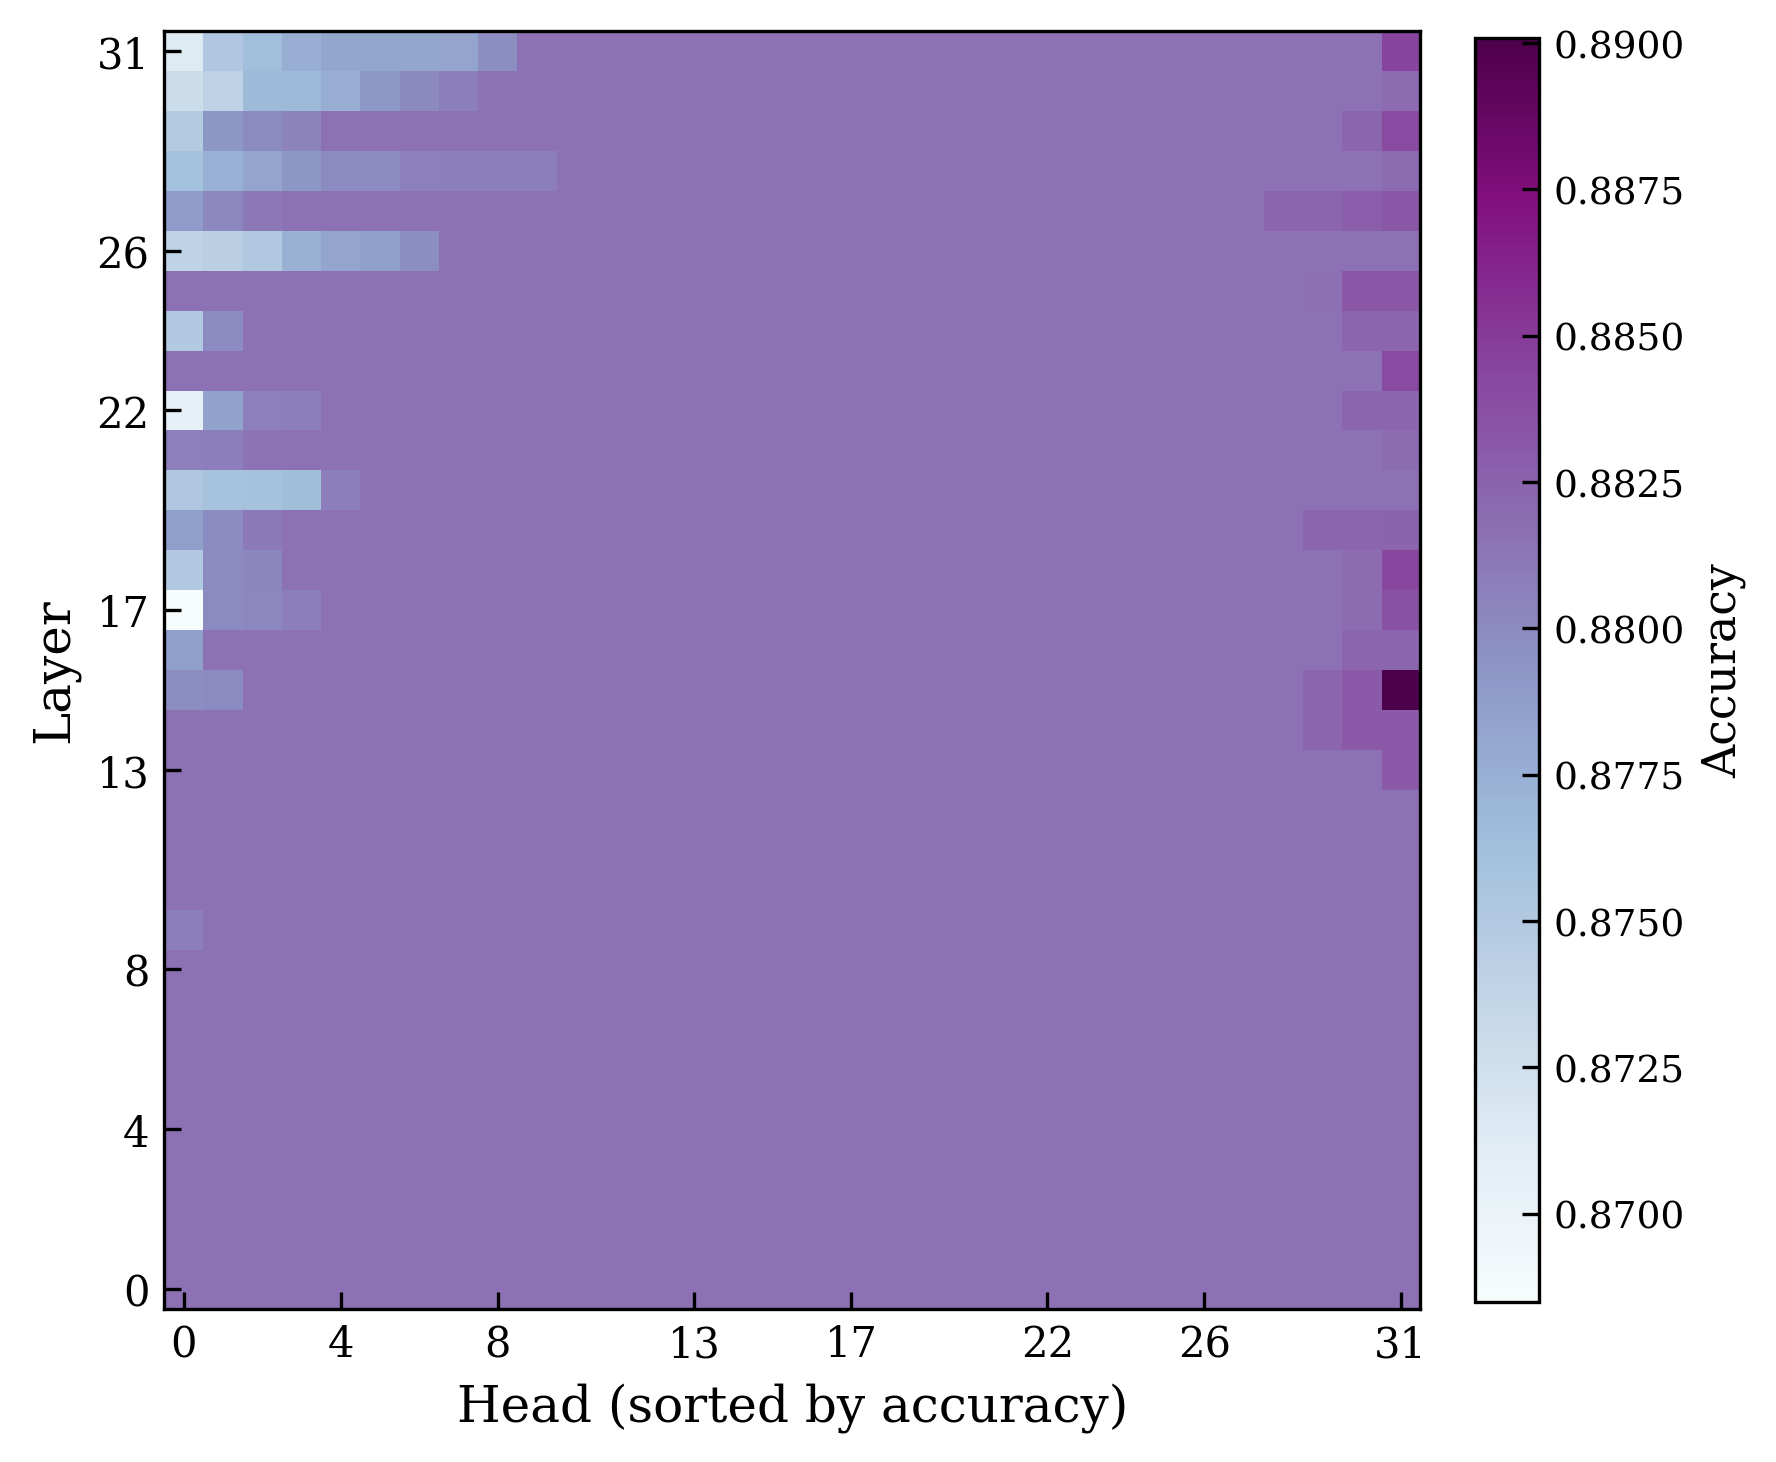

In [89]:
# ── Publication style (if not already set) ──
'''
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})
'''

predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)

fig, ax = plt.subplots(figsize=(6, 5))

pos = ax.imshow(predictor_accuracy_sorted, cmap="BuPu", aspect="auto", origin="lower")

ax.set_ylabel("Layer")
ax.set_xlabel("Head (sorted by accuracy)")
#ax.set_title("Attention Head Accuracies")

# Move x-axis labels/ticks to bottom (matshow puts them on top)
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")

# Reduce tick clutter
n_layers, n_heads = predictor_accuracy_sorted.shape
ax.set_xticks(np.linspace(0, n_heads - 1, min(n_heads, 8)).astype(int))
ax.set_yticks(np.linspace(0, n_layers - 1, min(n_layers, 8)).astype(int))

# Colorbar
cbar = fig.colorbar(pos, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()
#fig.savefig("../figures/probe.pdf", bbox_inches="tight", dpi=300)

In [90]:
from sklearn.metrics import roc_curve, auc

# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = labels

accuracies = []
fprs = []
precisions = []
recalls = []
f1s = []
probs = []
test_labels = []
mean_fpr_grid = np.linspace(0, 1, 200)
fold_tprs = []
fold_aucs = []

folds = [f for f in grouped_kfold_split(extracted_df['title'].values)]

for fold, (train_idx, test_idx) in enumerate(folds):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_bool = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_test).astype(bool)

    tp = int(((y_pred_bool == True) & (y_true == True)).sum())
    tn = int(((y_pred_bool == False) & (y_true == False)).sum())
    fp = int(((y_pred_bool == True) & (y_true == False)).sum())
    fn = int(((y_pred_bool == False) & (y_true == True)).sum())

    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else float('nan')
    fold_denom = fp + tn
    fpr = (fp / fold_denom) if fold_denom > 0 else float('nan')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    fprs.append(fpr)

    # Per-fold reporting
    n_pos = int(y_true.sum())
    n_neg = int((~y_true).sum())
    print(f"  Fold {fold}: n={len(y_test)} (pos={n_pos}, neg={n_neg}) | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  FPR={fpr:.4f}")

    # Calibration
    y_prob = model.predict_proba(X_test)[:, 1]
    probs.append(y_prob)
    test_labels.append(y_test)

    # AUROC
    fpr_fold, tpr_fold, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_fold, tpr_fold)
    fold_aucs.append(roc_auc)

    # Interpolate TPR onto common FPR grid
    interp_tpr = np.interp(mean_fpr_grid, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    fold_tprs.append(interp_tpr)

probs = np.concatenate(probs)
test_labels = np.concatenate(test_labels)

fold_tprs = np.array(fold_tprs)
mean_tpr = fold_tprs.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr = fold_tprs.std(axis=0)
mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print()
print(f"Attn head model avg. accuracy:   {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Attn head model avg. precision:  {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Attn head model avg. recall:     {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Attn head model avg. F1:         {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Attn head model avg. FPR:        {np.mean(fprs):.4f} ± {np.std(fprs):.4f}")

  Fold 0: n=236 (pos=14, neg=222) | Acc=0.9322  Prec=0.4375  Rec=0.5000  F1=0.4667  FPR=0.0405
  Fold 1: n=486 (pos=53, neg=433) | Acc=0.9383  Prec=0.8485  Rec=0.5283  F1=0.6512  FPR=0.0115
  Fold 2: n=270 (pos=37, neg=233) | Acc=0.8407  Prec=0.3333  Rec=0.1622  F1=0.2182  FPR=0.0515
  Fold 3: n=325 (pos=47, neg=278) | Acc=0.8523  Prec=0.0000  Rec=0.0000  F1=nan  FPR=0.0036
  Fold 4: n=253 (pos=36, neg=217) | Acc=0.8577  Prec=0.5000  Rec=0.1667  F1=0.2500  FPR=0.0276

Attn head model avg. accuracy:   0.8842 ± 0.0420
Attn head model avg. precision:  0.4239 ± 0.2735
Attn head model avg. recall:     0.2714 ± 0.2073
Attn head model avg. F1:         nan ± nan
Attn head model avg. FPR:        0.0270 ± 0.0177


### Calibration (reliability / trustworthiness)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.

In [91]:
def plot_calibration(
    ax,
    calibrations,          # list of dicts: {centers, means, ses, counts, color, label}
    title="",
    xlabel="Predicted Probability",
    ylabel="Observed Frequency",
    annotate=True,
    annotation_fontsize=7.5,
    legend_loc="upper left",
    xlim=(-0.03, 1.03),
    ylim=(-0.03, 1.03),
):
    """
    Plot one or more calibration curves on a single Axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    calibrations : list of dict
        Each dict must contain:
            centers : array-like – bin midpoints
            means   : array-like – observed positive rate per bin
            ses     : array-like – standard error per bin
            counts  : array-like – sample count per bin
            color   : str        – line / fill color
            label   : str        – legend label
    title, xlabel, ylabel : str
    annotate : bool
        If True, label each point with its bin count.
    annotation_fontsize : float
    legend_loc : str
    xlim, ylim : tuple
    """
    # ── Diagonal reference ──
    ax.plot(
        [0, 1], [0, 1],
        ls="--", color=COLORS["diag"], lw=0.8,
        label="Perfectly calibrated", zorder=1,
    )

    # ── Each calibration curve ──
    for cal in calibrations:
        centers = cal["centers"]
        means   = cal["means"]
        ses     = cal["ses"]
        counts  = cal["counts"]
        color   = cal["color"]
        label   = cal["label"]

        # Shaded ±1 SE band
        ax.fill_between(
            centers, means - ses, means + ses,
            alpha=0.18, color=color, edgecolor="none", zorder=2,
        )
        # Line + markers
        ax.plot(
            centers, means, "o-",
            color=color, ms=4, lw=1.4, label=label, zorder=3,
        )
        # Bin-count annotations
        if annotate:
            for x, y, n in zip(centers, means, counts):
                txt = ax.annotate(
                    f"$n$={n}", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=annotation_fontsize,
                    color="dimgray",
                )
                txt.set_path_effects([
                    mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
                ])

    # ── Axes formatting ──
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    # Lighten spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.4")
    ax.tick_params(width=0.6, color="0.4", labelsize=8)

    ax.legend(frameon=False, loc=legend_loc, fontsize=8)

In [92]:
cal_llama = compute_calibration(probs, test_labels)
best_t = fit_temperature_from_probs(probs, 1 - probs, test_labels)
probs_temp, probs_false_temp = apply_temperature_from_probs(probs, 1 - probs, best_t)
cal_llama_temp = compute_calibration(probs_temp, test_labels)

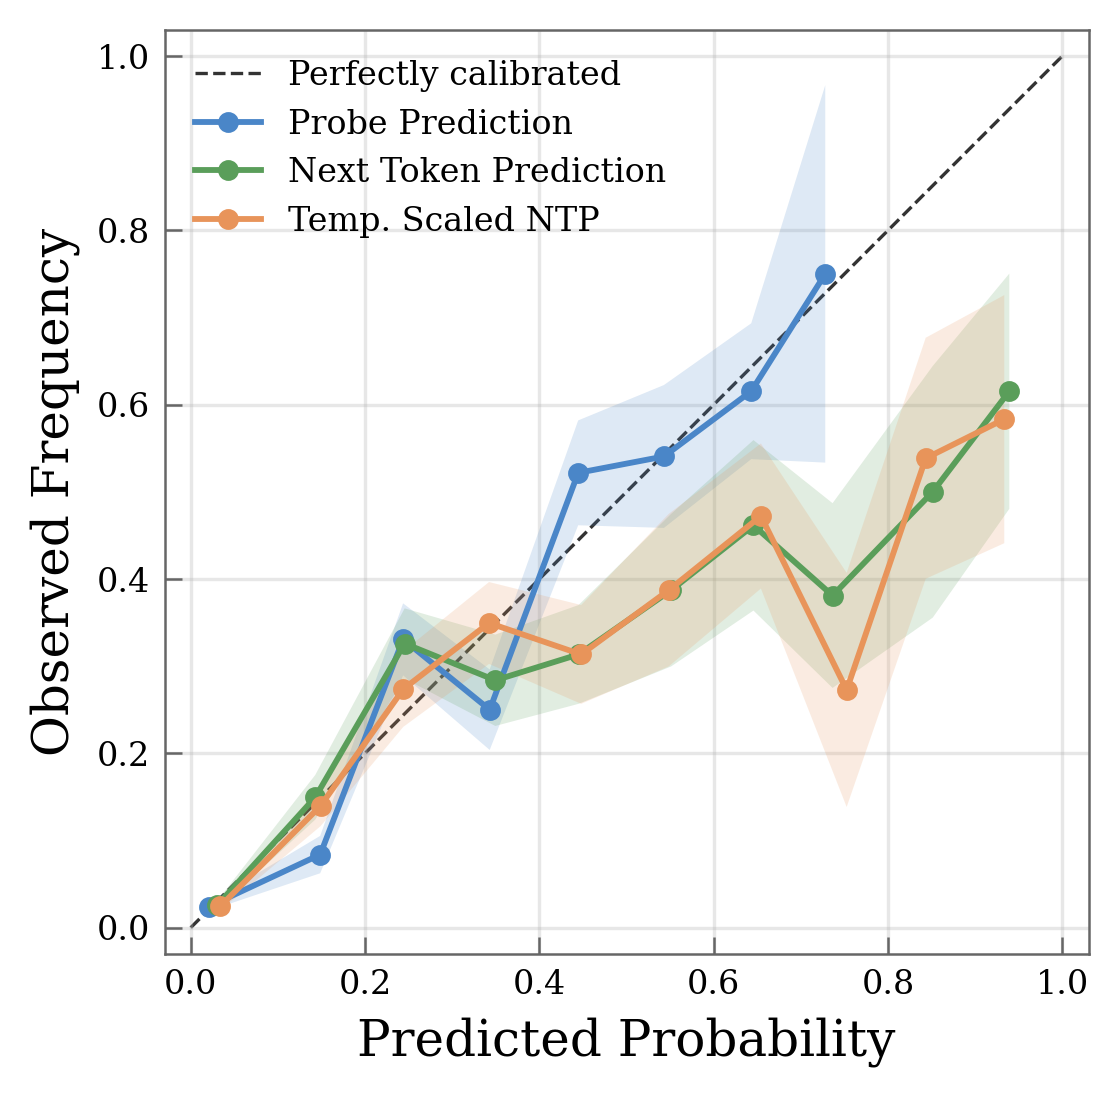

In [93]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_calibration(ax, [
    {**cal_llama, "color": "#4A86C8", "label": "Probe Prediction"},
    #{**cal_llama_temp, "color": "#ff9999", "label": "Temp. Scaled Probe Prediction"},
    {**cal_llama_baseline,   "color": "#5A9E5A", "label": "Next Token Prediction"},
    {**cal_llama_baseline_temp,   "color": "#E8945A", "label": "Temp. Scaled NTP"},
], title=None, annotate=False)
ax.grid(True, alpha=0.3)
#fig.savefig("../figures/calibration.pdf", bbox_inches="tight", dpi=300)

In [ ]:
# Evaluate performance across different thresholds
thresholds = np.linspace(0.5, 1.0, 11)  # 0.5, 0.6, 0.7, ..., 1.0

recovery_rates = []
hallucination_rates = []

# Get full predictions for all samples using fold predictions
probs_all = np.full(len(extracted_df), np.nan)

for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    probs_all[test_idx] = y_prob

# Get matching_status and validation labels
matching_status = extracted_df['matching_status'].to_numpy().astype(bool)
validation_labels = extracted_df['validation'].to_numpy().astype(bool)

for threshold in thresholds:
    # Apply threshold to probabilities
    y_pred_thresh = (probs_all >= threshold).astype(bool)
    n_pred = y_pred_thresh.sum()
    
    # Recovery rate: % of matched samples predicted as True
    n_matched = matching_status.sum()
    if n_matched > 0:
        matched_and_predicted = (matching_status & y_pred_thresh).sum()
        recovery_rate = matched_and_predicted / n_matched
    else:
        recovery_rate = np.nan
    
    # Hallucination rate: % predicted positive which are incorrect
    n_pred = y_pred_thresh.sum()
    if n_pred > 0:
        not_validated_and_predicted = ((~validation_labels) & y_pred_thresh).sum()
        hallucination_rate = not_validated_and_predicted / n_pred
    else:
        hallucination_rate = np.nan
    
    recovery_rates.append(recovery_rate)
    hallucination_rates.append(hallucination_rate)

recovery_rates = np.array(recovery_rates) * matching_recall
hallucination_rates = np.array(hallucination_rates)

# Create line plot with color gradient
fig, ax = plt.subplots(figsize=(6, 5))

# Plot line connecting points
scatter = ax.scatter(
    hallucination_rates, recovery_rates,
    c=thresholds, cmap='coolwarm', s=80, alpha=0.8, 
    edgecolors='black', linewidth=0.8, zorder=3
)

# Connect points with line
ax.plot(
    hallucination_rates, recovery_rates,
    color='gray', alpha=0.4, linewidth=1, zorder=1
)

ax.set_xlabel('Hallucination Rate', fontsize=14)
ax.set_ylabel('Recovery Rate', fontsize=14)
#ax.set_xlim(-0.05, 1.05)
#ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
#ax.set_aspect('equal')

# Add colorbar
cbar = fig.colorbar(scatter, ax=ax, label='Prediction Threshold')
cbar.set_label('Prediction Threshold', fontsize=14)

plt.tight_layout()
#fig.savefig("../figures/prediction_threshold.pdf", bbox_inches="tight", dpi=300)
plt.show()